In [1]:
import os
import h5py
import numpy as np
from scipy.integrate import solve_ivp
from scipy.stats.qmc import Halton
from time import time
import torch
import matplotlib.pyplot as plt
from joblib import Parallel, delayed  # For parallel execution



In [2]:
# File paths
old_file_path = "C:/Users/cqyzxy/Downloads/trials_many_alldata_v3.h5"
new_file_path = "C:/Users/cqyzxy/Downloads/trials_many_alldata_new_eqution_halton.h5"


In [85]:
with h5py.File(old_file_path, 'r') as old_data:
    # Extract parameter values
    P_old = old_data['P'][:]
    J_e_primes = P_old[:, 0]
    b_1_primes = P_old[:, 1]
    b_2_primes = P_old[:, 2]
    f_0_primes = P_old[:, 6]

    # Find the shortest length
    min_length = min(len(J_e_primes), len(b_1_primes), len(b_2_primes), len(f_0_primes))
    # Function to randomly reduce the length of a list
    def reduce_length(arr, target_length):
        if len(arr) > target_length:
            indices = np.random.choice(len(arr), target_length, replace=False)
            return arr[indices]
        return arr

    # Reduce lengths to the shortest length
    J_e_primes = reduce_length(J_e_primes, min_length)
    b_1_primes = reduce_length(b_1_primes, min_length)
    b_2_primes = reduce_length(b_2_primes, min_length)
    f_0_primes = reduce_length(f_0_primes, min_length)
    f_cr = 5.3e-3
    f_0_values = f_0_primes/f_cr
    h_0_values = P_old[:, 4]

time_grid = np.linspace(0, 1, 601)


In [86]:
b_1_primes.min()

-1.0844142

Constants

In [87]:
h_0_values = h_0_values*1e-6 # Convert to meters
p_0 = 12e-6

In [88]:
rho = 1e3 # Water density (g/L)
#P_c_hat = 12.1 # (micro m/s)  

Vw = 18e-6 # Molar volume of water (m^3/Mol)
c_0 = 302 # Serum Osmolarity (Mol/m^3)
sigma_0 = 0.045 # N/m
mu = 1.3e-3 # Pa.s

# Solute parameters
fcr = 0.002 # material property: critical FL concentration in mole frac
Mw_FL = 376 # molecular weight of Na_2FL, (g/mol)

# Naperian extinction coefficient
eps_f = 1.75e7 # m^-1 M^-1
# transmittance parameter
fcr2 = rho * fcr/Mw_FL
ts = 18.8 # Characteristic time scale (s). 

# ts should be a parameter as well. 


In [89]:
# l_values =(ts*sigma_0*h_0_values**3/mu)**0.25*10**2.25 # Multiplication with 1e2.25 is to ensure the unit of l is in micrometers
# l_values =(ts*sigma_0*h_0_values**3/mu)**0.25
# U_values = l_values/ts
# epsilon_values = h_0_values/l_values
# V_values = epsilon_values*U_values
# f0p2 = f_0_primes*rho/Mw_FL
# phi_values = eps_f*fcr2*h_0_values*1e6 # Multiplication with 1e6 is to adjust the units
phi_values = eps_f*fcr*h_0_values
Pc_values = p_0*Vw*c_0/(h_0_values/ts)
f_0_values = f_0_primes/f_cr


In [ ]:
Pc_values.max()


2.4525828

In [ ]:
print(min(h_0_values),max(h_0_values))


5.000286e-07 7.999943e-06


In [7]:
# Function to calculate I
def calculate_I(h, f, phi, I_0=1.0):
    return I_0 * (1 - np.exp(-phi * h * f)) / (1 + f ** 2)


In [8]:
halton_sampler = Halton(d=1, scramble=False, seed=42)
halton_sequence = halton_sampler.random(n=111563).flatten()
# Rescale to be in the range 0.5 to 1.0
h_e_range = [0.5*1e-6, 1*1e-6]

h_e_halton = h_e_range[0] + (h_e_range[1] - h_e_range[0]) * halton_sequence

J_e_values = (J_e_primes*1e-6/60)*ts/(h_0_values)

b_1_values = b_1_primes * ts

b_2_values = b_2_primes * ts

h_e_values = np.array(h_e_halton) / np.array(h_0_values)


In [9]:
# Check if all lists have the same length
lengths = [len(J_e_values), len(b_1_values), len(b_2_values), len(h_e_values), len(f_0_values), len(Pc_values), len(phi_values)]

if all(length == lengths[0] for length in lengths):
    print(f"All lists have the same length: {lengths[0]}")
else:
    print("The lists do not have the same length.")

All lists have the same length: 111563


In [10]:
# Differential system (P_c is a constant and does not need to be passed as an argument)
def differential_system(t, y, J_e, b_1, b_2, h_e, P_c):
    h, c = y
    g_t = b_1 * np.exp(-b_2 * t)
    dh_dt = -g_t * h - J_e * (1 - (h_e / h) ** 3) + P_c * (c - 1)
    dc_dt = -g_t * c - dh_dt * (c / h)
    return [dh_dt, dc_dt]

def generate_and_store_dataset():  
    #valid_h, valid_c, valid_f, valid_I, valid_p = [], [], [], [], []
    # count = 0
    # for i, (J_e, b_1, b_2, h_e, f_0, Pc, phi) in enumerate(zip(J_e_values, b_1_values, b_2_values, h_e_values, f_0_values, Pc_values, phi_values)):
    fixed_length = len(time_grid) 
    
    def solve_single_instance(i):
        J_e, b_1, b_2, h_e, f_0, Pc, phi = (J_e_values[i], b_1_values[i], b_2_values[i],
                                            h_e_values[i], f_0_values[i], Pc_values[i], phi_values[i])
        y0 = [1.0, 1.0]
        sol = solve_ivp(differential_system, [0., 1.], y0, t_eval=time_grid, 
                        args=(J_e, b_1, b_2, h_e, Pc), method='LSODA')  # Faster for stiff equations
        
        if np.max(sol.y[0]) > 1.1:
            return None  # Skip rejected cases
        elif sol.y[0].shape[0] < fixed_length:
            return None
        else:
            h = sol.y[0]
            c = sol.y[1] / sol.y[0]
            f = f_0 * c
            FI = ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            I0 = 1 / FI[1]
            I = I0 * ((-np.exp(-phi * f * sol.y[0])) + 1) / ((f ** 2) + 1)
            return h, c, f, I, (J_e, b_1, b_2, h_e, f_0, Pc, phi)

    results = Parallel(n_jobs=-1)(delayed(solve_single_instance)(i) for i in range(1000))
 
    filtered_results = [res for res in results if res is not None]
    print(len(filtered_results[0]))

 
    valid_h, valid_c, valid_f, valid_I, valid_p = map(np.array, zip(*filtered_results))


    valid_h = np.array(valid_h)
    valid_c = np.array(valid_c)
    valid_f = np.array(valid_f)
    valid_I = np.array(valid_I)
    valid_p = np.array(valid_p)
 
    print(f"Total accepted parameter sets: {valid_h.shape[0]}")
    return valid_h, valid_c, valid_f, valid_I, valid_p


In [11]:
start = time()
valid_h, valid_c, valid_f, valid_I, valid_p = generate_and_store_dataset()
end = time()
print(f"Time taken: {end - start:.2f} seconds")


5
Total accepted parameter sets: 974
Time taken: 12.41 seconds


In [12]:
print(valid_h.shape, valid_c.shape, valid_f.shape, valid_I.shape, valid_p.shape)

(974, 601) (974, 601) (974, 601) (974, 601) (974, 7)


In [143]:
indices = np.where(valid_c[:, -1] < 0.9)[0]

# Print the indices
print("Indices of rows where the last element is less than 1:")
print(indices)


Indices of rows where the last element is less than 1:
[     6      8     15 ... 108308 108309 108314]


In [ ]:
len(indices)


18983

0
Parameters for n=0:
Je: 0.6846510171890259
b1: 3.418181896209717
b2: 13.270587921142578
he: 0.15094339693128936
f0: 0.22060959041118622
Pc: 0.3702223598957062
phi: 0.1159375011920929


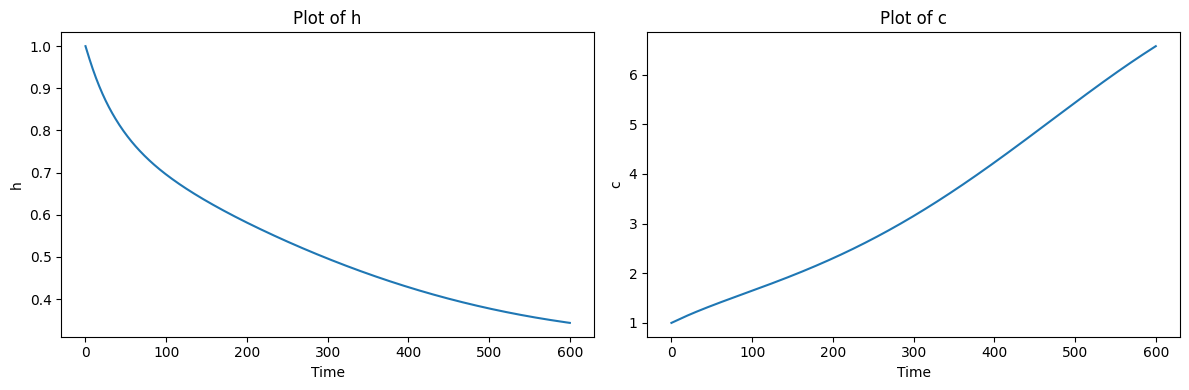

In [82]:
#n = np.random.randint(0, len(valid_h))
n=0
print(n)
print(f"Parameters for n={n}:")
print(f"Je: {J_e_values[n]}")
print(f"b1: {b_1_values[n]}")
print(f"b2: {b_2_values[n]}")
print(f"he: {h_e_values[n]}")
print(f"f0: {f_0_values[n]}")
print(f"Pc: {Pc_values[n]}")
print(f"phi: {phi_values[n]}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # 1 row, 2 columns

# Plot h
axes[0].plot(valid_h[n])
axes[0].set_title('Plot of h')
axes[0].set_xlabel('Time')
axes[0].set_ylabel('h')

# Plot c
axes[1].plot(valid_c[n])
axes[1].set_title('Plot of c')
axes[1].set_xlabel('Time')
axes[1].set_ylabel('c')

plt.tight_layout()
#plt.savefig("example_fixed.pdf")
plt.show()

# plt.plot(data_I[n])
# plt.title('Plot of I')
# plt.xlabel('Time')
# plt.ylabel('I')
# plt.show()


86128


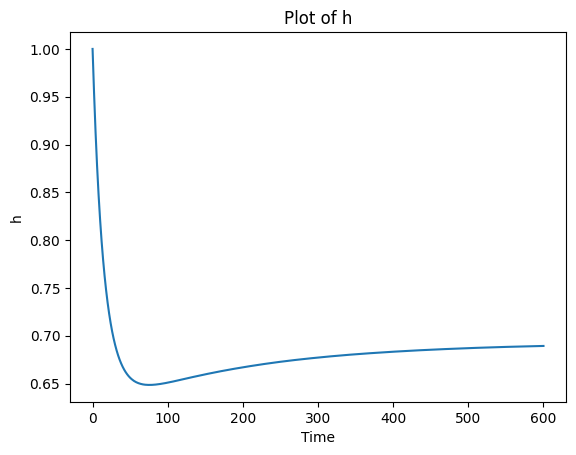

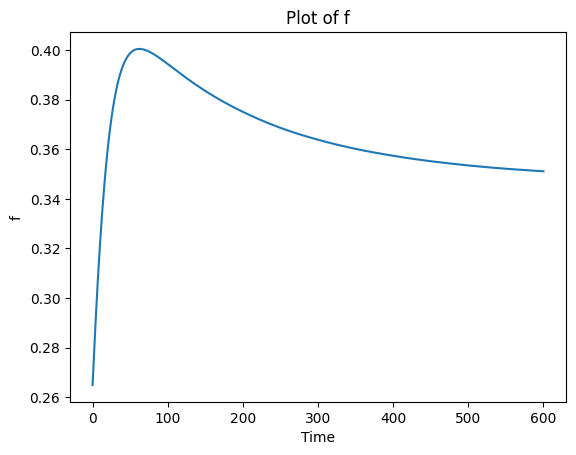

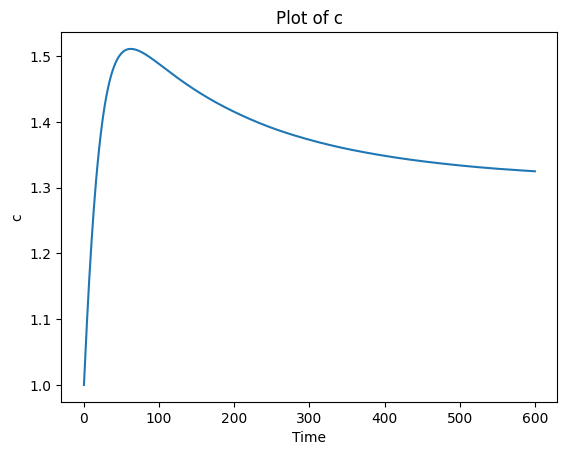

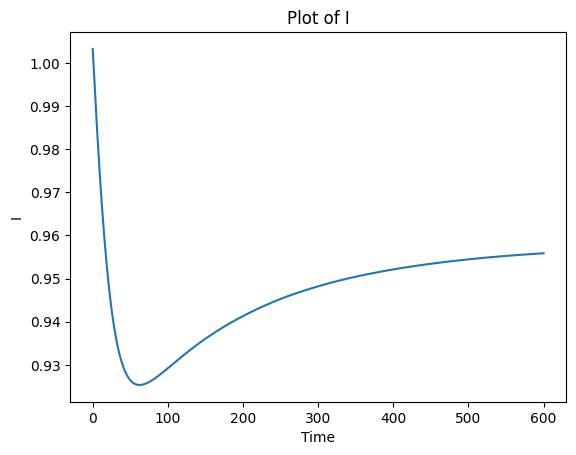

In [15]:
n = np.random.randint(0, len(data_h))
print(n)
plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

19122


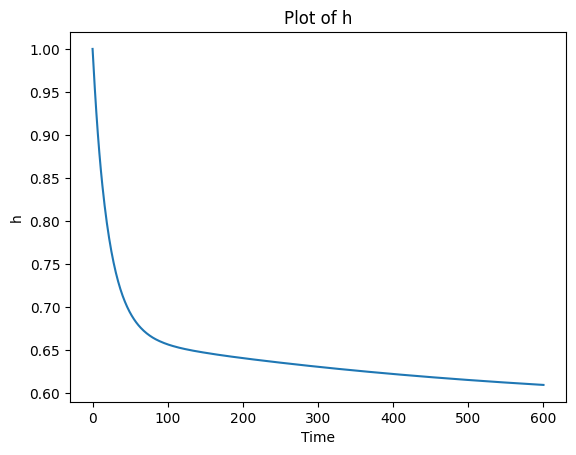

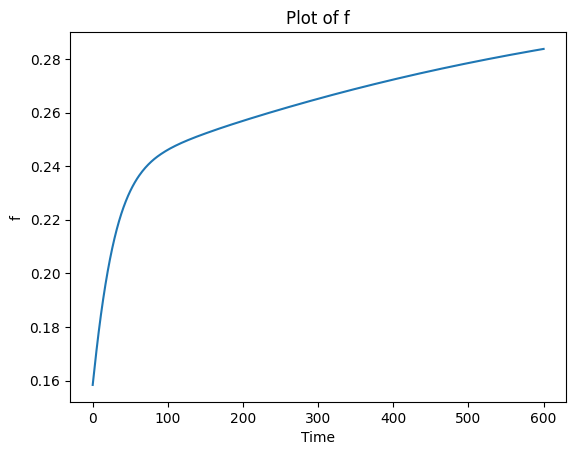

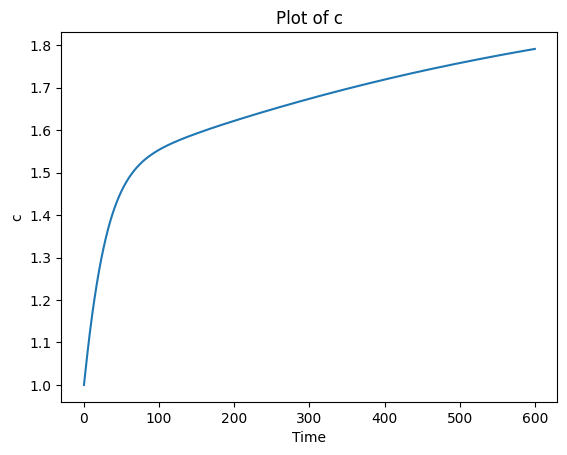

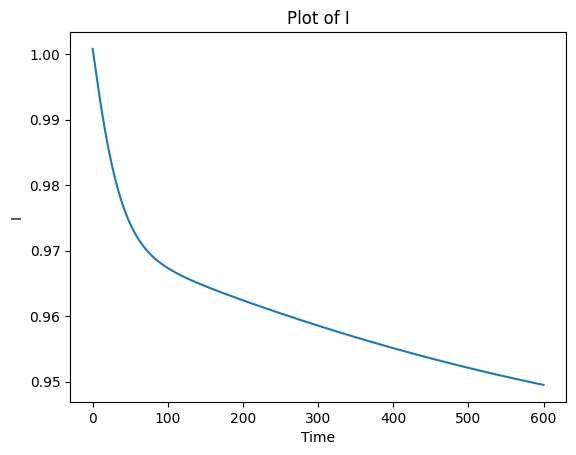

In [16]:
n = np.random.randint(0, len(data_h))
print(n)
plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

26748


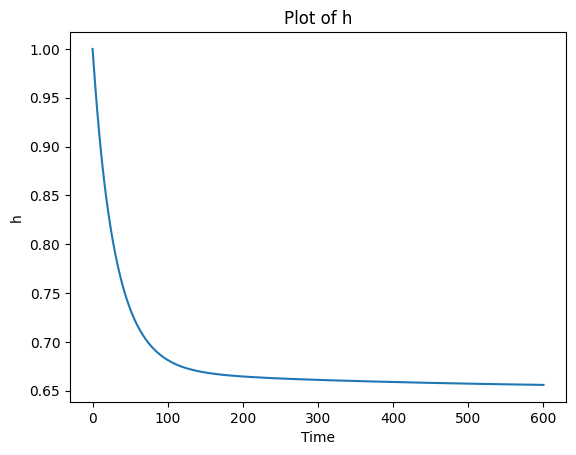

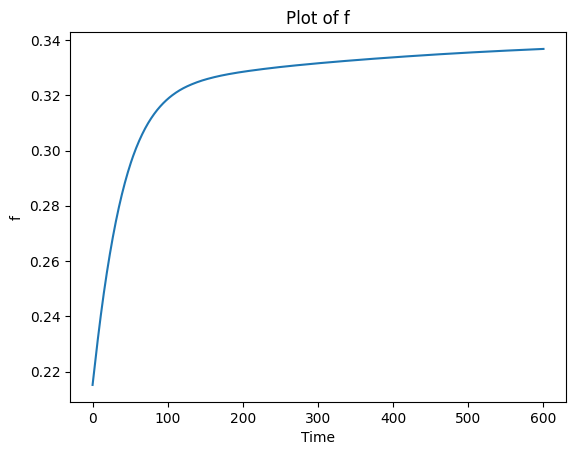

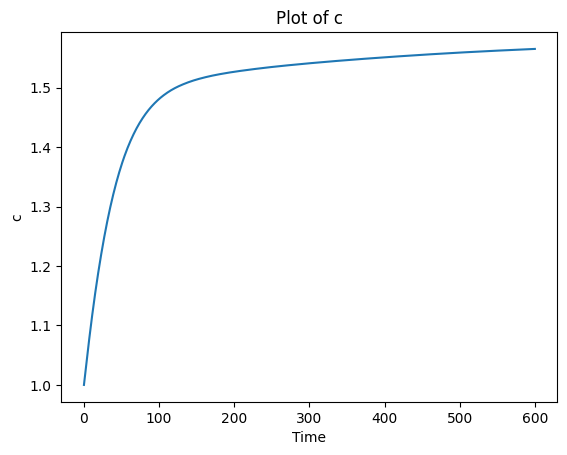

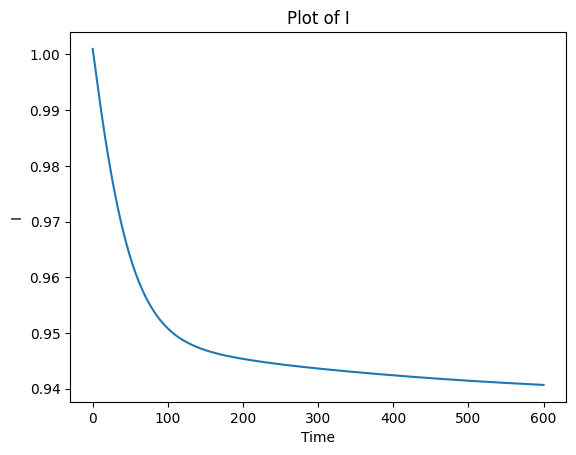

In [17]:
n = np.random.randint(0, len(data_h))
print(n)
plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()

78860


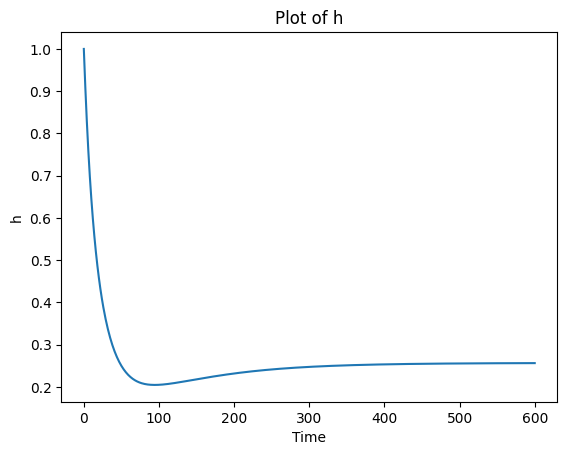

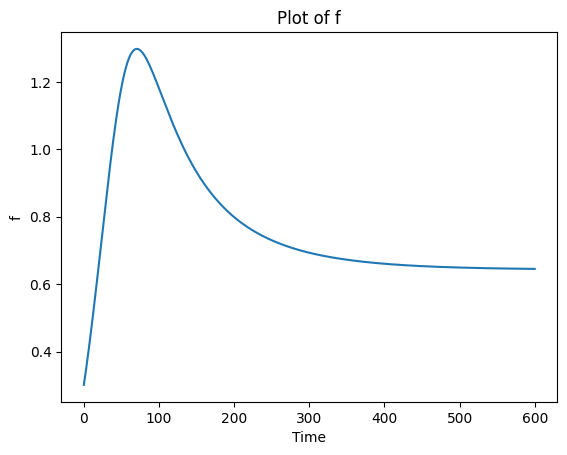

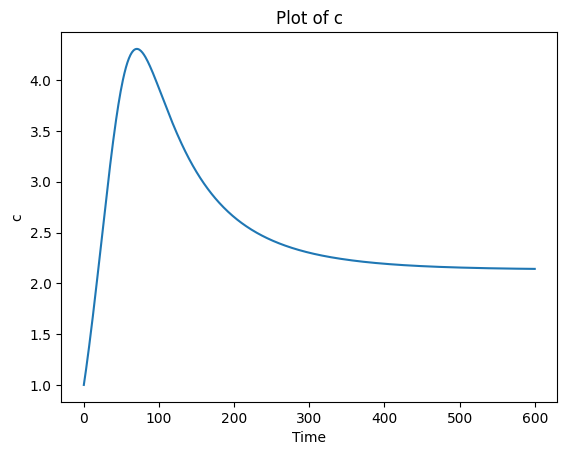

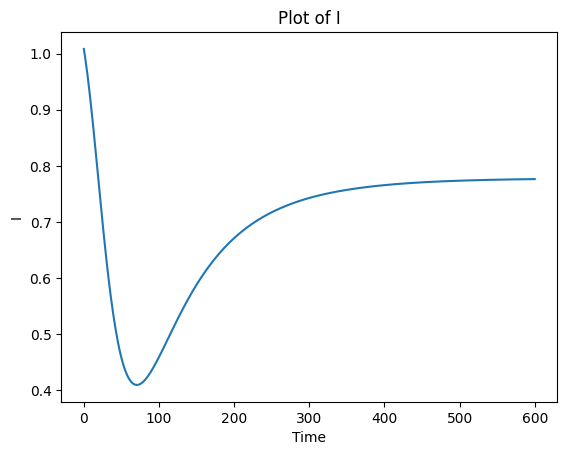

In [18]:
n = np.random.randint(0, len(data_h))
print(n)
plt.plot(data_h[n])
plt.title('Plot of h')
plt.xlabel('Time')
plt.ylabel('h')
plt.show()

plt.plot(data_f[n])
plt.title('Plot of f')
plt.xlabel('Time')
plt.ylabel('f')
plt.show()

plt.plot(data_c[n])
plt.title('Plot of c')
plt.xlabel('Time')
plt.ylabel('c')
plt.show()

plt.plot(data_I[n])
plt.title('Plot of I')
plt.xlabel('Time')
plt.ylabel('I')
plt.show()